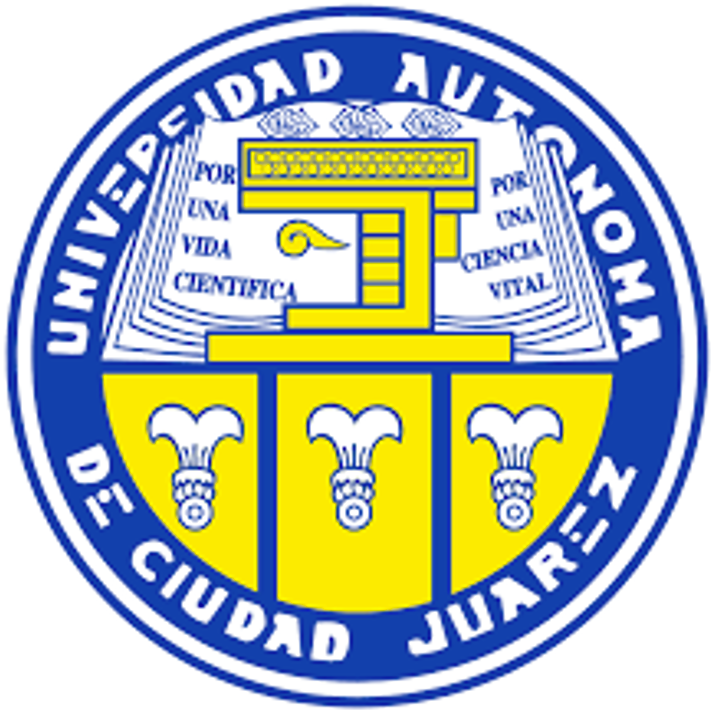




## Tarea 7: Ejercicios: Visualización semántica de palabras utilizando embeddings y t-SNE
## Nombre: Sergio Trejo
## Matricula: 261539
## Materia: Procesamiento de Lenguaje Natural_A_Presencial_260206


Explorar la representación semántica de palabras e identifica los diferentes dominios temáticos contenidos en el conjunto de datos proporcionado mediante la visualización 2D de embeddings de palabras. Realiza y define las actividades de preprocesamiento del texto (si lo crees necesario) para que fácilmente puedas identificar en la visualización lo siguiente:

1.	¿Cuántos dominios o grupos de datos puedes identificar visualmente en la gráfica?
2.	¿Cuáles son esos dominios?

**Instrucciones adicionales:**
* Genera la gráfica 2D de los embeddings de palabras utilizando t-SNE.
* Visualiza en la gráfica las palabras de cada uno de los puntos.
* De manera manual, encierra aproximadamente con óvalos los grupos o dominios que hayas identificado.
* Incluye la gráfica final y tus observaciones en el documento de entrega.



In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import gensim.downloader as api
from sklearn.manifold import TSNE
from sentence_transformers import SentenceTransformer

/home/sergioai/miniconda3/envs/ml/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#Cargar el dataset
df = pd.read_csv("Ejercicios de Representación de textos - Embeddings.csv")
df.head()

#Procesamiento de texto
frases = df["frase"].str.lower()      # convertir a minúsculas
frases = frases.str.strip()           # eliminar espacios al inicio y final

frases = df["frase"].tolist()
print("Numero de frases:", len(frases))

Numero de frases: 148


In [3]:
#Cargar el modelo de embeddings
print("Cargando el modelo SBERT en español...")

model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

print("Modelo cargado!")

Cargando el modelo SBERT en español...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 18784.83it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo cargado!


In [4]:
#Generar los embeddings para las frases
embeddings = model.encode(frases)
print("Dimension de los embeddings:", embeddings.shape)

Dimension de los embeddings: (148, 384)


In [5]:
#Reducir la dimensionalidad a 2D usando t-SNE

tsne = TSNE(
    n_components=2,
    perplexity=15,
    random_state=42,
    init="pca",
)

X_2d = tsne.fit_transform(embeddings)
print("Dimensión reducida a 2D:", X_2d.shape)

Dimensión reducida a 2D: (148, 2)


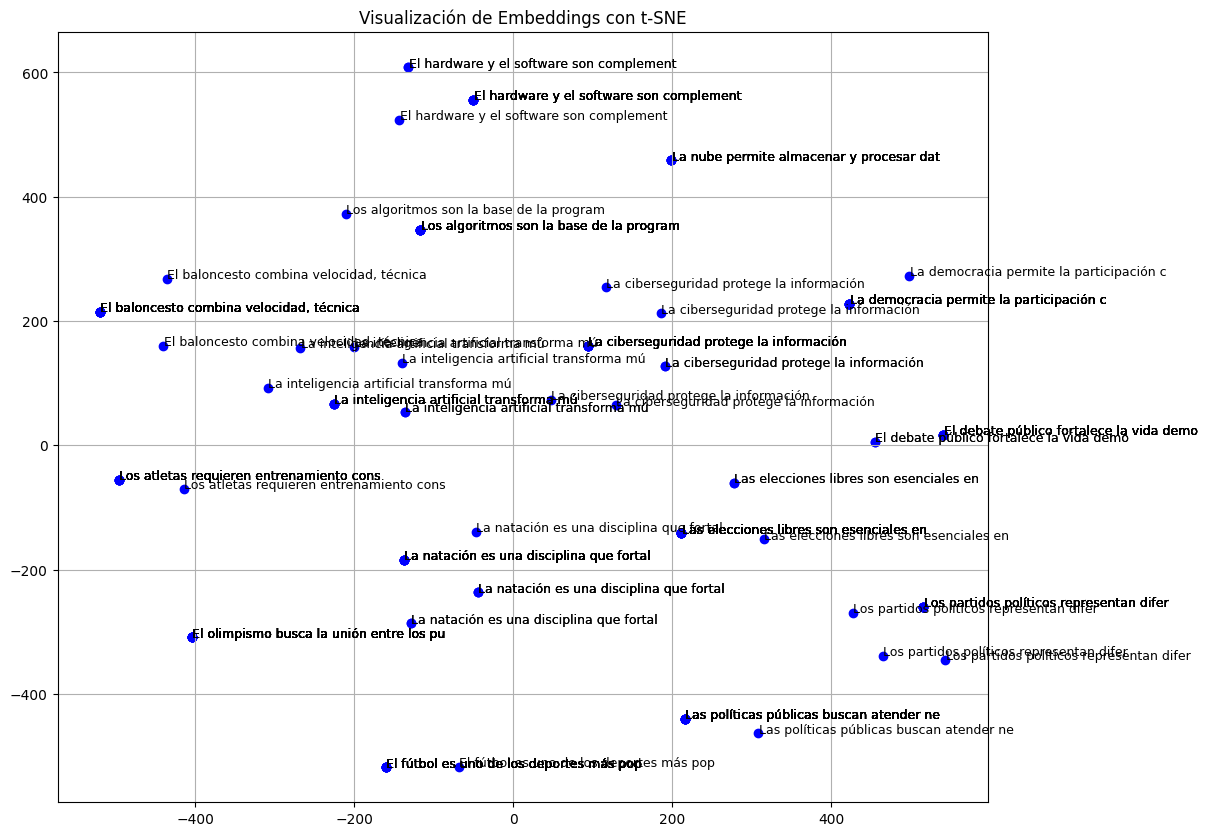

In [6]:
#Visualizacion

plt.figure(figsize=(12, 10))

for i, frase in enumerate(frases):

    x = X_2d[i, 0]
    y = X_2d[i, 1]

    plt.scatter(x, y, color="blue")
    plt.text(x + 0.5, y + 0.5, frase[:40], fontsize=9)
plt.title("Visualización de Embeddings con t-SNE")
plt.grid()
plt.show()

## ¿Cuántos dominios o grupos de datos puedes identificar visualmente en la gráfica?

**Se distinguen 3 grupos principales:**
* Dominio 1 — Tecnología – Circulo Rojo
* Dominio 2 — Deportes – Circulo Verde
* Dominio 3 — Política / sociedad – Circulo Azul

La visualización generada mediante t-SNE permite representar en dos dimensiones los embeddings de las frases del conjunto de datos. A partir de esta representación fue posible observar como las frases con significados similares tienden a agruparse en el espacio semántico. En la grafica se identificaron 3 dominios principales (tecnología, deportes y política). Esto demuestra que los modelos de embeddings nos ayudan a detectar relaciones semánticas entre los textos como también dominios donde pertenecen.


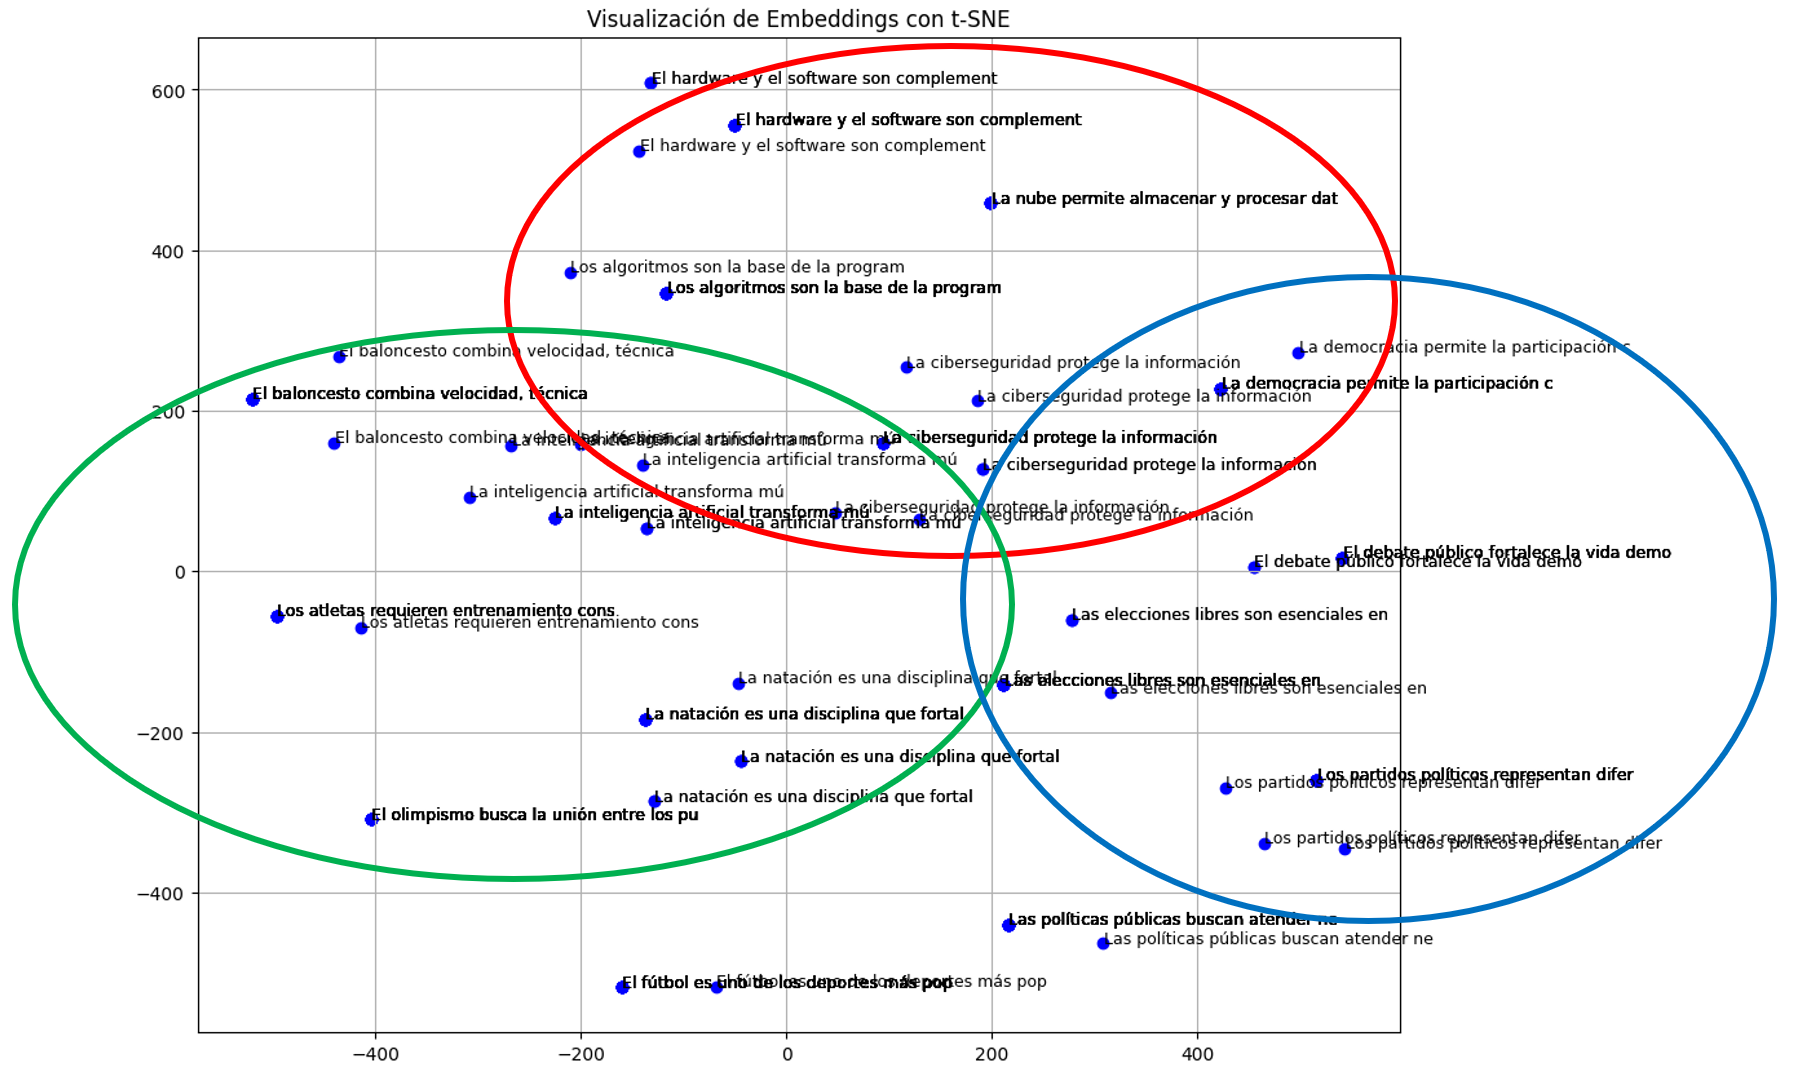

